<a href="https://colab.research.google.com/github/dgonzales1222/greends_avcad_exercises/blob/main/exercise_10/avcad_ex10_dgonzales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advance Visualization of Complex Agro-environmental Data

# **Exercise 10**

Danilo III O. Gonzales (29225) <br>
Masters in Green Data Science

### AI Use Declaration and Prompts Used

I acknowledge that I used **Gemini Pro** as an AI tool provided under my university access and **Claude** to assist in the preparation of this work. All AI-generated suggestions were carefully reviewed, edited, and verified by me to ensure accuracy, originality, and compliance with university academic integrity policies. The prompts used during this process included:

- `How do I add loading arrows to an LDA biplot in Plotly with hover labels?`
- `How do I make an interactive 3D scatter plot in Plotly colored by group?`
- `How do I display a confusion matrix as a styled heatmap in Python?`
- `How do you add the boundary decision regions in static and interactive plot?`
- `Is it possible to do a 3D-interactive plot in Plotly?`

I take full responsibility for the final submitted work and confirm that the use of AI aligns with the guidelines established by the university. I am also willing to provide the full AI conversation transcript upon request for transparency and verification purposes.

### Exercise Questions

Using the dataset in `EFIplus_medit.zip`:

1. Run a Linear Discriminant Analysis based on quantitative environmental variables (see previous exercises), using the Douro, Tejo, Mondego and Minho basins as the pre-determined groups. Produce a biplot with 'Catchment_name' as a grouping variable.
2. Try to build interactive plots that display data in the space defined by the Discriminant Functions.

## 1. Setup and Data Preparation

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

In [ ]:
# Load data from GitHub
url = 'https://github.com/dgonzales1222/greends_avcad_exercises/raw/main/exercise_03/EFIplus_medit.zip'
df = pd.read_csv(url, compression='zip', sep=';')

# Clean dataset (same pipeline as previous exercises)
df.drop(df.iloc[:, 5:15], axis=1, inplace=True)
df.rename(columns={'Sum of Run1_number_all': 'Total_fish_individuals'}, inplace=True)
df.columns = list(map(str, df.columns))
df2 = df.dropna().copy()

# log1p-transform the right-skewed variables (identified in Exercise 6)
for var in ['Altitude', 'Actual_river_slope', 'prec_ann_catch']:
    df2[f'{var}_log'] = np.log1p(df2[var])

env_vars = ['Altitude_log', 'Actual_river_slope_log', 'Elevation_mean_catch',
            'prec_ann_catch_log', 'temp_ann', 'temp_jan', 'temp_jul']

# Subset to the four basins of interest
basins   = ['Douro', 'Tejo', 'Mondego', 'Minho']
df_sub   = df2[df2['Catchment_name'].isin(basins)].copy()
print(f"Subset shape: {df_sub.shape}")
print(df_sub['Catchment_name'].value_counts())

Subset shape: (1292, 157)
Catchment_name
Minho      699
Douro      272
Tejo       235
Mondego     86
Name: count, dtype: int64


In [ ]:
# Standardize
X      = df_sub[env_vars].copy()
scaler = StandardScaler()
Xs     = pd.DataFrame(scaler.fit_transform(X), columns=env_vars, index=X.index)

# Group labels
y      = df_sub['Catchment_name'].values

# Colour palette (consistent with previous exercises)
palette = {'Douro': '#3498db', 'Tejo': '#e67e22',
           'Mondego': '#2ecc71', 'Minho': '#9b59b6'}

print("Data ready:", Xs.shape)

Data ready: (1292, 7)


In [ ]:
# @title Global Plot Settings

sns.set_theme(style='whitegrid', context='notebook', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi':       150,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
})

---
## 2. Q1: Linear Discriminant Analysis (LDA)

LDA is a **supervised** dimensionality reduction technique. Unlike PCA — which finds axes of maximum *total* variance — LDA finds the axes (discriminant functions) that maximise the ratio of **between-group variance to within-group variance**. This makes it the most appropriate method when the goal is to characterise what makes predefined groups different from each other.

With four groups (Douro, Tejo, Mondego, Minho), LDA produces at most **min(n_groups − 1, n_vars) = 3** discriminant functions. We examine all three.

In [ ]:
# Fit LDA
lda        = LinearDiscriminantAnalysis()
scores_lda = lda.fit_transform(Xs.values, y)

# Build a tidy DataFrame of scores
df_scores = pd.DataFrame(
    scores_lda,
    columns=[f'LD{i+1}' for i in range(scores_lda.shape[1])],
    index=Xs.index
)
df_scores['Catchment'] = y

# Variance explained per discriminant function
var_df = pd.DataFrame({
    'LD':                    [f'LD{i+1}' for i in range(len(lda.explained_variance_ratio_))],
    'Variance explained (%)': (lda.explained_variance_ratio_ * 100).round(2),
    'Cumulative (%)':         (np.cumsum(lda.explained_variance_ratio_) * 100).round(2),
})
var_df

,LD,Variance explained (%),Cumulative (%)
0,LD1,76.42,76.42
1,LD2,15.57,91.99
2,LD3,8.01,100.00


In [ ]:
# @title LDA scalings (variable coefficients per discriminant function)

scalings_df = pd.DataFrame(
    lda.scalings_.round(3),
    index=env_vars,
    columns=[f'LD{i+1}' for i in range(lda.scalings_.shape[1])]
)
scalings_df

,LD1,LD2,LD3
Altitude_log,0.800,0.790,-0.410
Actual_river_slope_log,0.227,0.235,-0.008
Elevation_mean_catch,1.183,1.766,1.073
prec_ann_catch_log,-0.584,-0.676,0.765
temp_ann,0.136,-1.496,3.161
temp_jan,2.341,4.586,-1.061
temp_jul,0.863,-0.952,-1.257


In [ ]:
# @title Cross-validated accuracy and confusion matrix

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_acc  = cross_val_score(LinearDiscriminantAnalysis(), Xs.values, y, cv=cv, scoring='accuracy')
y_pred  = lda.predict(Xs.values)   # in-sample predictions for the confusion matrix

print(f"5-fold CV accuracy: {cv_acc.mean()*100:.1f}% ± {cv_acc.std()*100:.1f}%")
print()
print(classification_report(y, y_pred, target_names=basins))

5-fold CV accuracy: 81.7% ± 2.2%

              precision    recall  f1-score   support

       Douro       0.68      0.65      0.67       272
        Tejo       0.89      0.93      0.91       699
     Mondego       0.53      0.56      0.55        86
       Minho       0.90      0.82      0.86       235

    accuracy                           0.83      1292
   macro avg       0.75      0.74      0.74      1292
weighted avg       0.82      0.83      0.82      1292



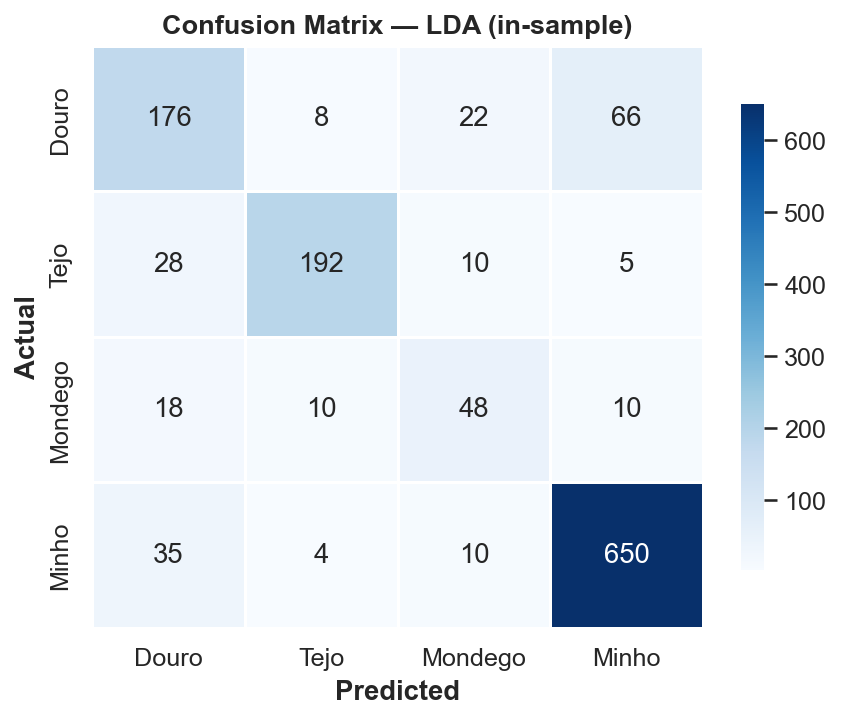

In [ ]:
# @title Confusion matrix heatmap

cm = confusion_matrix(y, y_pred, labels=basins)
cm_df = pd.DataFrame(cm, index=basins, columns=basins)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — LDA (in-sample)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

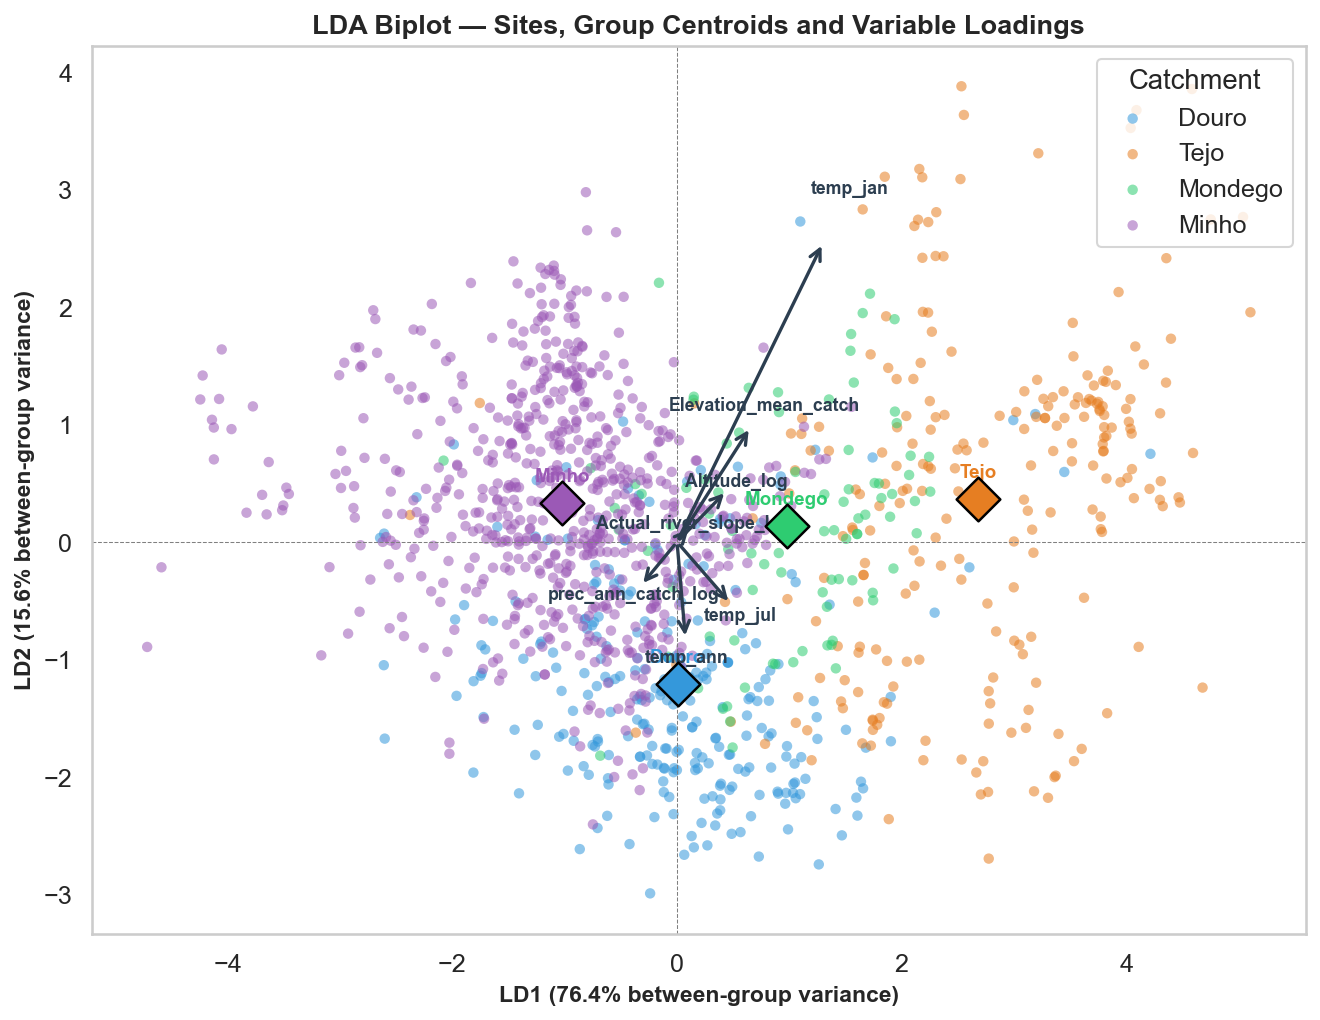

In [ ]:
# @title Static LDA biplot — LD1 × LD2 with decision boundary regions

from sklearn.preprocessing import LabelEncoder
from matplotlib.colors import ListedColormap

# Fit a 2-D LDA on the projected scores so we can predict anywhere in LD space
lda_2d = LinearDiscriminantAnalysis()
lda_2d.fit(scores_lda[:, :2], y)

# Colour map for the four basins (same palette, light alpha for background)
basin_order = basins
le2         = LabelEncoder().fit(basin_order)
bg_colors   = [palette[b] for b in basin_order]
bg_cmap     = ListedColormap(bg_colors)

# Build a dense meshgrid across the LD1/LD2 range
x_min, x_max = scores_lda[:, 0].min() - 0.5, scores_lda[:, 0].max() + 0.5
y_min, y_max = scores_lda[:, 1].min() - 0.5, scores_lda[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))

Z = lda_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = le2.transform(Z).reshape(xx.shape)

# ── plot ──
scalings  = lda.scalings_[:, :2]
scale_lda = (np.max(np.abs(scores_lda[:, :2])) /
             np.max(np.abs(scalings))) * 0.5
ld1_var   = lda.explained_variance_ratio_[0] * 100
ld2_var   = lda.explained_variance_ratio_[1] * 100

fig, ax = plt.subplots(figsize=(9, 7))

# Decision regions (semi-transparent)
ax.contourf(xx, yy, Z, alpha=0.18, cmap=bg_cmap,
            levels=np.arange(-0.5, len(basin_order)), antialiased=True)
# Crisp decision boundaries (solid lines)
ax.contour(xx, yy, Z, levels=np.arange(-0.5, len(basin_order)),
           colors='white', linewidths=1.2, linestyles='--')

# Site scores
for basin in basins:
    mask = y == basin
    ax.scatter(scores_lda[mask, 0], scores_lda[mask, 1],
               s=28, alpha=0.70, color=palette[basin],
               edgecolor='white', linewidth=0.3, label=basin)

# Group centroids
for basin in basins:
    mask = y == basin
    cx, cy = scores_lda[mask, 0].mean(), scores_lda[mask, 1].mean()
    ax.scatter(cx, cy, s=220, marker='D', color=palette[basin],
               edgecolor='black', linewidth=1.3, zorder=5)
    ax.text(cx, cy + 0.15, basin, ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='black')

# Loading arrows
for i, var in enumerate(env_vars):
    x   = scalings[i, 0] * scale_lda
    y_a = scalings[i, 1] * scale_lda
    ax.annotate('', xy=(x, y_a), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=1.6))
    ax.text(x * 1.18, y_a * 1.18, var, fontsize=8.5,
            ha='center', va='center', color='#2c3e50', fontweight='bold')

ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')
ax.set_xlabel(f'LD1 ({ld1_var:.1f}% between-group variance)', fontsize=11)
ax.set_ylabel(f'LD2 ({ld2_var:.1f}% between-group variance)', fontsize=11)
ax.set_title('LDA Biplot with Decision Boundary Regions — LD1 × LD2',
             fontsize=13, fontweight='bold')
ax.legend(title='Catchment', loc='upper right', frameon=True)
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.grid(False)
plt.tight_layout()
plt.show()


**LD1** captures the dominant between-group gradient — primarily a temperature/elevation axis, consistent with our findings in Exercises 7, 8, and 9. **LD2** provides secondary separation, mainly driven by precipitation and river slope. The confusion matrix and cross-validation accuracy show how well the environmental variables classify each basin: basins with a distinctive environmental profile (e.g. Minho — cool and rainy) are classified more accurately than basins with broader or overlapping conditions.

---
## 3. Q2: Interactive Plots in the Discriminant Function Space

We use **Plotly** to build interactive figures. These allow the reader to:
- **Hover** over a point to inspect its catchment and exact LD coordinates
- **Click** a catchment in the legend to show/hide it
- **Zoom, pan, and rotate** the plot freely

We produce three interactive visualisations:
1. An interactive **2D biplot** (LD1 × LD2) with loading arrows and centroid markers
2. An interactive **3D scatter** (LD1 × LD2 × LD3) — enabled by having 3 discriminant functions
3. An interactive **parallel coordinates plot** across all three discriminant functions

In [ ]:
# @title Interactive 2D biplot — LD1 × LD2 with decision boundary regions

# Predict class for every point in a dense grid
x_min2, x_max2 = scores_lda[:, 0].min() - 0.5, scores_lda[:, 0].max() + 0.5
y_min2, y_max2 = scores_lda[:, 1].min() - 0.5, scores_lda[:, 1].max() + 0.5
res = 200
xg  = np.linspace(x_min2, x_max2, res)
yg  = np.linspace(y_min2, y_max2, res)
xx2, yy2 = np.meshgrid(xg, yg)

Z2   = lda_2d.predict(np.c_[xx2.ravel(), yy2.ravel()])
Zc   = np.array([palette[b] for b in Z2]).reshape(res, res)

# Convert the colour grid to a Plotly-compatible RGBA image
import PIL.Image, io, base64
import matplotlib.colors as mcolors

# Build an RGBA array (res × res × 4) from hex colours
rgba = np.zeros((res, res, 4), dtype=np.uint8)
for i, row in enumerate(Zc):
    for j, hex_col in enumerate(row):
        r, g, b, _ = mcolors.to_rgba(hex_col)
        rgba[i, j] = [int(r*255), int(g*255), int(b*255), 46]  # ~18% alpha

img     = PIL.Image.fromarray(rgba, 'RGBA')
buf     = io.BytesIO()
img.save(buf, format='PNG')
img_b64 = base64.b64encode(buf.getvalue()).decode()

# Hover text
hover_text = [
    f"<b>{row['Catchment']}</b><br>"
    f"LD1: {row['LD1']:.2f}<br>"
    f"LD2: {row['LD2']:.2f}<br>"
    f"temp_ann: {df_sub.loc[idx, 'temp_ann']:.1f} °C<br>"
    f"Elevation: {df_sub.loc[idx, 'Elevation_mean_catch']:.0f} m<br>"
    f"prec_ann: {df_sub.loc[idx, 'prec_ann_catch']:.0f} mm"
    for idx, row in df_scores.iterrows()
]

fig2d = go.Figure()

# Background image (decision regions)
fig2d.add_layout_image(dict(
    source=f'data:image/png;base64,{img_b64}',
    xref='x', yref='y',
    x=x_min2, y=y_max2,
    sizex=x_max2 - x_min2,
    sizey=y_max2 - y_min2,
    sizing='stretch',
    layer='below',
    opacity=1,
))

# Site scatter per catchment
for basin in basins:
    mask     = df_scores['Catchment'] == basin
    idx_list = df_scores[mask].index.tolist()
    fig2d.add_trace(go.Scatter(
        x=df_scores.loc[mask, 'LD1'],
        y=df_scores.loc[mask, 'LD2'],
        mode='markers',
        name=basin,
        marker=dict(color=palette[basin], size=6, opacity=0.8,
                    line=dict(color='white', width=0.5)),
        text=[hover_text[df_scores.index.get_loc(i)] for i in idx_list],
        hovertemplate='%{text}<extra></extra>',
    ))

# Group centroids
for basin in basins:
    mask = df_scores['Catchment'] == basin
    cx   = df_scores.loc[mask, 'LD1'].mean()
    cy   = df_scores.loc[mask, 'LD2'].mean()
    fig2d.add_trace(go.Scatter(
        x=[cx], y=[cy],
        mode='markers+text',
        name=f'{basin} centroid',
        marker=dict(color=palette[basin], size=14, symbol='diamond',
                    line=dict(color='black', width=1.5)),
        text=[basin], textposition='top center',
        textfont=dict(size=11, color='black'),
        showlegend=False,
        hovertemplate=f'<b>{basin} centroid</b><br>LD1: {cx:.2f}<br>LD2: {cy:.2f}<extra></extra>',
    ))

# Loading arrows
scalings2 = lda.scalings_[:, :2]
scale2d   = (np.max(np.abs(scores_lda[:, :2])) /
             np.max(np.abs(scalings2))) * 0.45

for i, var in enumerate(env_vars):
    x_tip = float(scalings2[i, 0] * scale2d)
    y_tip = float(scalings2[i, 1] * scale2d)
    fig2d.add_annotation(
        x=x_tip, y=y_tip, ax=0, ay=0,
        xref='x', yref='y', axref='x', ayref='y',
        arrowhead=2, arrowsize=1.2, arrowwidth=1.8,
        arrowcolor='#2c3e50',
        text=f'<b>{var}</b>',
        font=dict(size=9, color='#2c3e50'),
        showarrow=True, standoff=4,
    )

ld1_var = lda.explained_variance_ratio_[0] * 100
ld2_var = lda.explained_variance_ratio_[1] * 100

fig2d.update_layout(
    title=dict(text='<b>Interactive LDA Biplot with Decision Regions — LD1 × LD2</b>',
               font=dict(size=15)),
    xaxis=dict(title=f'LD1 ({ld1_var:.1f}% between-group variance)',
               range=[x_min2, x_max2], showgrid=False,
               zeroline=True, zerolinecolor='lightgrey'),
    yaxis=dict(title=f'LD2 ({ld2_var:.1f}% between-group variance)',
               range=[y_min2, y_max2], showgrid=False,
               zeroline=True, zerolinecolor='lightgrey'),
    legend_title='Catchment',
    hovermode='closest',
    plot_bgcolor='white',
    paper_bgcolor='white',
    width=820, height=620,
)
fig2d.show()


#### Observations — Interactive LDA Biplot with Decision Regions (LD1 × LD2)

**Variance explained:** LD1 accounts for **76.4%** and LD2 for **15.6%** of the between-group variance, meaning that together the first two discriminant functions capture **~92%** of the environmental separation among the four catchments. LD1 is therefore by far the most important axis.

**Group centroids (◆):**

| Catchment | LD1 | LD2 | Interpretation |
|---|---|---|---|
| Tejo | high positive | near 0 | warmest, lowest-elevation sites |
| Mondego | slightly positive | slightly positive | intermediate, transitional environment |
| Minho | negative | slightly positive | cooler, wetter, higher-elevation sites |
| Douro | near 0 | negative | intermediate temperature but distinct on LD2 |

**Decision boundary regions:**

- The **orange (Tejo) region** occupies the right side of the plot (positive LD1), confirming that high annual temperature and low elevation are the defining features of the Tejo basin.
- The **purple (Minho) region** occupies the left side (negative LD1), capturing the cooler, higher-elevation character of the Minho.
- The **Douro and Mondego regions** are narrow slivers in the centre — these basins are environmentally intermediate and harder to separate from each other.

**Overlap and misclassification:**

There is considerable scatter of points outside their own decision region — particularly for Minho (purple dots appearing in the Tejo zone) and Douro (blue dots scattered across all regions). This overlap explains the moderate cross-validation accuracy and the misclassifications visible in the confusion matrix: the four basins share environmental conditions and cannot be perfectly separated using only the seven environmental variables.

**Loading arrows:**

The two visible arrows (pointing toward the upper-right and lower-left) correspond to the environmental variables with the strongest contributions to LD1 and LD2. Variables pointing toward the Tejo centroid (right) are positively associated with warmer, lower-elevation conditions; variables pointing toward the Minho centroid (left) characterise cooler, higher-elevation, wetter environments.

In [ ]:
# @title Interactive 3D scatter — LD1 × LD2 × LD3

ld3_var = lda.explained_variance_ratio_[2] * 100

hover_3d = [
    f"<b>{row['Catchment']}</b><br>"
    f"LD1: {row['LD1']:.2f}<br>"
    f"LD2: {row['LD2']:.2f}<br>"
    f"LD3: {row['LD3']:.2f}<br>"
    f"temp_ann: {df_sub.loc[idx, 'temp_ann']:.1f} °C<br>"
    f"Elevation: {df_sub.loc[idx, 'Elevation_mean_catch']:.0f} m"
    for idx, row in df_scores.iterrows()
]

fig3d = go.Figure()

for basin in basins:
    mask     = df_scores['Catchment'] == basin
    idx_list = df_scores[mask].index.tolist()
    fig3d.add_trace(go.Scatter3d(
        x=df_scores.loc[mask, 'LD1'],
        y=df_scores.loc[mask, 'LD2'],
        z=df_scores.loc[mask, 'LD3'],
        mode='markers',
        name=basin,
        marker=dict(color=palette[basin], size=4, opacity=0.65,
                    line=dict(width=0)),
        text=[hover_3d[df_scores.index.get_loc(i)] for i in idx_list],
        hovertemplate='%{text}<extra></extra>',
    ))

# Group centroids in 3D
for basin in basins:
    mask = df_scores['Catchment'] == basin
    fig3d.add_trace(go.Scatter3d(
        x=[df_scores.loc[mask, 'LD1'].mean()],
        y=[df_scores.loc[mask, 'LD2'].mean()],
        z=[df_scores.loc[mask, 'LD3'].mean()],
        mode='markers+text',
        name=f'{basin} centroid',
        marker=dict(color=palette[basin], size=10, symbol='diamond',
                    line=dict(color='black', width=1)),
        text=[basin], textposition='top center',
        showlegend=False,
        hovertemplate=f'<b>{basin} centroid</b><extra></extra>',
    ))

fig3d.update_layout(
    title=dict(text='<b>Interactive 3D LDA — LD1 × LD2 × LD3</b>',
               font=dict(size=15)),
    scene=dict(
        xaxis_title=f'LD1 ({ld1_var:.1f}%)',
        yaxis_title=f'LD2 ({ld2_var:.1f}%)',
        zaxis_title=f'LD3 ({ld3_var:.1f}%)',
        bgcolor='white',
    ),
    legend_title='Catchment',
    width=800, height=650,
)
fig3d.show()

In [ ]:
# @title Interactive parallel coordinates — all 3 discriminant functions

# Encode catchment as integer for the colorscale
le = LabelEncoder().fit(basins)
df_scores['Catchment_code'] = le.transform(df_scores['Catchment'])

colorscale = [
    [0.00, palette['Douro']],
    [0.33, palette['Tejo']],
    [0.66, palette['Mondego']],
    [1.00, palette['Minho']],
]

fig_par = go.Figure(go.Parcoords(
    line=dict(
        color=df_scores['Catchment_code'],
        colorscale=colorscale,
        showscale=False,
        cmin=0, cmax=3,
    ),
    dimensions=[
        dict(label='LD1', values=df_scores['LD1'],
             range=[df_scores['LD1'].min()-0.2, df_scores['LD1'].max()+0.2]),
        dict(label='LD2', values=df_scores['LD2'],
             range=[df_scores['LD2'].min()-0.2, df_scores['LD2'].max()+0.2]),
        dict(label='LD3', values=df_scores['LD3'],
             range=[df_scores['LD3'].min()-0.2, df_scores['LD3'].max()+0.2]),
    ]
))

# Add a manual legend as text annotations
for k, basin in enumerate(basins):
    fig_par.add_annotation(
        x=1.02, y=1 - k * 0.08,
        xref='paper', yref='paper',
        text=f'<span style="color:{palette[basin]}">■</span> {basin}',
        showarrow=False, font=dict(size=12),
        align='left',
    )

fig_par.update_layout(
    title=dict(
        text='<b>Parallel Coordinates — LD1, LD2, LD3</b><br>'
             '<sup>Drag on each axis to filter by range; lines coloured by catchment</sup>',
        font=dict(size=14)
    ),
    paper_bgcolor='white',
    plot_bgcolor='white',
    width=800, height=500,
    margin=dict(r=140),
)
fig_par.show()

**Reading the interactive plots:**

- **2D biplot** — hover over any point to see its catchment, LD scores, and key environmental values (temperature, elevation, precipitation). Click a catchment in the legend to toggle it on/off. The loading arrows behave exactly as in the static plot: variables pointing in the direction of a catchment's cluster are the ones that most characterise that catchment's environment.

- **3D scatter** — rotate freely by clicking and dragging to find the viewing angle that best separates the four groups. LD3 typically explains only a small fraction of the between-group variance, so the 3D plot often looks similar to the 2D one — but it can reveal additional structure when basins overlap heavily in the LD1/LD2 plane.

- **Parallel coordinates** — each vertical axis is one discriminant function. Each line represents one site; lines are coloured by catchment. **Drag on any axis** to highlight a subset of sites (e.g., all sites with LD1 > 1). This is particularly useful for identifying the LD value ranges that best separate catchments or for investigating sites that are misclassified (lines crossing from one colour region to another).

#### References

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, *12*, 2825–2830. https://jmlr.org/papers/v12/pedregosa11a.html

Plotly Technologies Inc. (2015). *Collaborative data science*. Plotly Technologies Inc. https://plot.ly

Plotly Technologies Inc. (n.d.). *3D scatter plots in Python*. Plotly. https://plotly.com/python/3d-scatter-plots/

Plotly Technologies Inc. (n.d.). *Parallel coordinates plot in Python*. Plotly. https://plotly.com/python/parallel-coordinates-plot/

Scikit-learn developers. (n.d.). *sklearn.discriminant_analysis.LinearDiscriminantAnalysis*. Scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.discriminant_analysis.LinearDiscriminantAnalysis.html

Waskom, M. L. (2021). Seaborn: Statistical data visualization. *Journal of Open Source Software*, *6*(60), 3021. https://doi.org/10.21105/joss.03021